#**TextVectorization() Layer**

#*How It Works*

The TextVectorization() layer in Keras automates / simplifies much of the textual pre-processing we might want to do. By default, it simply changes all text to lowercase, removes punctuation, and splits into 1-grams based on white space. Some integers are reserved in the resulting encoding. Most notably, the value of 1 is reserved for tokens that did not appear in the original corpus that was used to construct the integer encoding ([UNK]). A code of 0 is reserved for an "ignore" flag, identified by a masking layer.

In [1]:
import tensorflow as tf
import string
import re

from tensorflow import keras

def custom_standardization_fn(string_tensor):
    lowercase_string = tf.strings.lower(string_tensor) # We convert upper case characters to lowercase.
    return tf.strings.regex_replace(
        lowercase_string, f"[{re.escape(string.punctuation)}]", "") # We find and remove punctuation.

def custom_split_fn(string_tensor):
    return tf.strings.split(string_tensor) # By default the separator is white space.

text_vectorization = keras.layers.TextVectorization(
    output_mode="int",
    #standardize=custom_standardization_fn,
    #split=custom_split_fn,
)

dataset = [
    "I write, erase, rewrite",
    "Erase again, and then",
    "A poppy blooms.",
]

text_vectorization.adapt(dataset)
text_vectorization.get_vocabulary()

['',
 '[UNK]',
 np.str_('erase'),
 np.str_('write'),
 np.str_('then'),
 np.str_('rewrite'),
 np.str_('poppy'),
 np.str_('i'),
 np.str_('blooms'),
 np.str_('and'),
 np.str_('again'),
 np.str_('a')]

Let's try using this layer to encode a sentence.

In [3]:
vocabulary = text_vectorization.get_vocabulary()

test_sentence = "I like to write practice sentences about a poppy that blooms again and again..."
encoded_sentence = text_vectorization(test_sentence)
print(test_sentence)
print(encoded_sentence.numpy())

inverse_vocab = dict(enumerate(vocabulary))
decoded_sentence = " ".join(inverse_vocab[int(i)] for i in encoded_sentence)
print(decoded_sentence)

I like to write practice sentences about a poppy that blooms again and again...
[ 7  1  1  3  1  1  1 11  6  1  8 10  9 10]
i [UNK] [UNK] write [UNK] [UNK] [UNK] a poppy [UNK] blooms again and again


#*Incorporating Into TF Dataset Pipeline*

There is a textfile equivalent function to what we'd seen previously for image data, called text_dataset_from_directory(). The folder structure works the same way as before and individual observations / documents should appear as separate .txt files in the folder.

Let's try this out using the IMDB Review dataset (an un-processed copy of it)...

In [4]:
!curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar -xf aclImdb_v1.tar.gz
!rm -r aclImdb/train/unsup
!cat aclImdb/train/pos/4077_10.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 80.2M  100 80.2M    0     0  3064k      0  0:00:26  0:00:26 --:--:-- 8172k
I first saw this back in the early 90s on UK TV, i did like it then but i missed the chance to tape it, many years passed but the film always stuck with me and i lost hope of seeing it TV again, the main thing that stuck with me was the end, the hole castle part really touched me, its easy to watch, has a great story, great music, the list goes on and on, its OK me saying how good it is but everyone will take there own best bits away with them once they have seen it, yes the animation is top notch and beautiful to watch, it does show its age in a very few parts but that has now become part of it beauty, i am so glad it has came out on DVD as it is one of my top 10 films of all time. Buy it or rent it just see it, best viewing is at night alone with drin

We now have the root folder with test and train directories. Inside each of those directories we have neg and pos subdirectories, which in turn contain lots of .txt files (one per movie review).

In [5]:
!ls aclImdb/test/neg

0_2.txt      11874_4.txt  2500_2.txt  4376_1.txt  6252_1.txt  8128_4.txt
10000_4.txt  11875_3.txt  2501_3.txt  4377_4.txt  625_2.txt   8129_4.txt
10001_1.txt  11876_4.txt  250_1.txt   4378_4.txt  6253_1.txt  8130_4.txt
10002_3.txt  11877_1.txt  2502_1.txt  4379_4.txt  6254_4.txt  8131_1.txt
10003_3.txt  11878_3.txt  2503_3.txt  4380_3.txt  6255_1.txt  813_1.txt
1000_3.txt   11879_2.txt  2504_3.txt  4381_3.txt  6256_2.txt  8132_3.txt
10004_2.txt  11880_3.txt  2505_1.txt  4382_3.txt  6257_4.txt  8133_4.txt
10005_2.txt  11881_2.txt  2506_1.txt  438_2.txt   6258_2.txt  8134_2.txt
10006_2.txt  11882_2.txt  2507_1.txt  4383_4.txt  6259_4.txt  8135_1.txt
10007_4.txt  1188_2.txt   2508_1.txt  4384_1.txt  6260_2.txt  8136_4.txt
10008_4.txt  11883_4.txt  2509_1.txt  4385_2.txt  6261_1.txt  8137_1.txt
10009_3.txt  11884_2.txt  2510_3.txt  4386_1.txt  6262_4.txt  8138_2.txt
10010_2.txt  11885_1.txt  2511_4.txt  4387_1.txt  6263_2.txt  8139_4.txt
10011_1.txt  11886_1.txt  2512_2.txt  4388_3.txt  62

Here, we are going to start by creating a validation sample (so we have train, validation and test). To do this, we will siphon off 20% of the files in each category (pos and neg), and put them into a new folder (validation). We will first shuffle the files before selecting which ones to copy.

In [6]:
import os, pathlib, shutil, random

base_dir = pathlib.Path("aclImdb")
val_dir = base_dir / "val"
train_dir = base_dir / "train"
for category in ("neg", "pos"):
    os.makedirs(val_dir / category)
    files = os.listdir(train_dir / category)
    random.Random(1337).shuffle(files)
    num_val_samples = int(0.2 * len(files))
    val_files = files[-num_val_samples:]
    for fname in val_files:
        shutil.move(train_dir / category / fname,
                    val_dir / category / fname)

Now we can make our text datasets...

In [7]:
from tensorflow import keras
batch_size = 32

train_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/train", batch_size=batch_size
)
val_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/val", batch_size=batch_size
)
test_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/test", batch_size=batch_size
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


Let's see what these datasets look like. Each batch of inputs is a set of 32 observations. Each observation is a string tensor. We have 32 labels for our 32 strings, which are 1-0 binary integer values.

In [8]:
for inputs, targets in train_ds:
    print("inputs.shape:", inputs.shape) # We have 32 reviews per batch.
    print("inputs.dtype:", inputs.dtype) # They are strings.
    print("targets.shape:", targets.shape) # We have 32 labels per batch.
    print("targets.dtype:", targets.dtype) # They are integers.
    print("inputs[0]:", inputs[0]) # Here is the first example
    print("targets[0]:", targets[0])
    break

inputs.shape: (32,)
inputs.dtype: <dtype: 'string'>
targets.shape: (32,)
targets.dtype: <dtype: 'int32'>
inputs[0]: tf.Tensor(b'The first word which comes into my mind after watching this movie is "beauty". Beauty is all around, in actors\' play (Andie is superb as always), in well designed shots, and in authors\' red line idea - the Love.<br /><br />I think the Kenny\'s character is the only white spot in these three womens\' otherwise boring and predictable life. His interaction makes Andie\'s character living as entertaining as it could possibly be. When he\'s gone, it became obvious that we cannot really appreciate and hold to our inner believes and sacred desires.<br /><br />The fact that Andie successfully recovers from this loss is nothing bad, instead it shows that life prevails in any forms, even in this small British village, which is shown perfectly.<br /><br />Another reason I love this movie is that it is so British in all ways - all that houses and "fags" and accents :)))

Now we can apply our TextVectorization layer to the datasets. We are processing all the text ahead of time in the TF Dataset object, rather than processing it inside our network during the training process, because it will be faster.

In [9]:
text_vectorization = keras.layers.TextVectorization(
    max_tokens=20000, # We'll limit our vocabulary to the 20,000 most frequent words.
    output_mode="multi_hot", # This creates a 'bag of words' representation where each review is represented by which words from the vocabulary are present (1) or absent (0).
    # output_mode="count", # If we wanted to count how many times each word appears, we would use "count".
    # output_mode="tf_idf", # For a more advanced weighting based on how unique words are, we could use "tf-idf".
)

# We need to prepare the text data so the vectorizer can learn the vocabulary.
# This line takes our training dataset (train_ds), which has both text and labels,
# and creates a new dataset that only contains the text reviews (dropping the labels).
text_only_train_ds = train_ds.map(lambda x, y: x)

# Now, we teach the text_vectorization layer about the words in our training data.
# The 'adapt' function goes through all the text in 'text_only_train_ds'
# and builds the vocabulary of the most frequent 20,000 words.
text_vectorization.adapt(text_only_train_ds)

# After the vectorizer has learned the vocabulary, we can use it to convert our text reviews
# into the multi-hot encoded numerical format that our model can understand.
# We do this for the training, validation, and test datasets.
# The lambda function here applies the text_vectorization to the text (x)
# and keeps the original label (y).
binary_1gram_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4) # We use multiple processes (4) to speed this up.

binary_1gram_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)

binary_1gram_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)

Now each *new* dataset yields batches of vectorized / processed versions of the observation's text, and the associated label. Our 1-gram multi-hot encoded representation is a matrix with 20k columns, 1's and 0's for word presence.

In [10]:
for x, y in train_ds:
  print(x[0])
  break

for x, y in binary_1gram_train_ds:
  print(x[0])
  break

tf.Tensor(b'So don\'t even think about renting this from the shops, because this is one hell of a bad movie. You\'d think that JJ Abrahams had written this movie. Basically, a rat is flushed down the toilet and somehow has to get back out. Fans of the completely terrible "Shrek" might enjoy, but "Wallace & Gromit" fans will probably turn away in disgust. Also, why didn\'t they do it in plasticine or clay? I mean, CGI animation?? For an AARDMAN movie??!! Obviously, Aardman lazed around while they let Dreamworks do the whole thing. Wrong, wrong, WRONG!!! Nearly every single character is awful, apart from that freaky frog guy, who is just right for a movie villain. But everything else about the movie is DULL, DULL, DULL!!! I almost fell asleep with boredom watching this movie. No, wait, actually, I DID fall asleep with boredom watching this movie. It\'s just terrible. But thankfully, it\'s not as bad as "Shrek."', shape=(), dtype=string)
tf.Tensor([1 1 1 ... 0 0 0], shape=(20000,), dtype=

#*Train a Model*

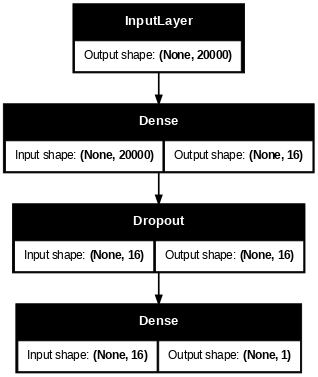

In [11]:
inputs = keras.Input(shape=(20000,)) # Here we have 20k columns as input for each observation.
x = keras.layers.Dense(16, activation="relu")(inputs)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

keras.utils.plot_model(model,show_shapes=True,dpi=60)

And, now we can train and then test the model...

In [12]:
callbacks = [
    keras.callbacks.ModelCheckpoint("binary_1gram.keras",
                                    save_best_only=True)
]

history = model.fit(binary_1gram_train_ds.cache(),  # Note: using .cache will make it so file opening and data reading are up front, not during each epoch
          validation_data=binary_1gram_val_ds.cache(),
          epochs=10,
          callbacks=callbacks)

model = keras.models.load_model("binary_1gram.keras")

print(f"Test acc: {model.evaluate(binary_1gram_test_ds)[1]:.3f}")

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8271 - loss: 0.4111 - val_accuracy: 0.8858 - val_loss: 0.2912
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8957 - loss: 0.2780 - val_accuracy: 0.8910 - val_loss: 0.2828
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9123 - loss: 0.2433 - val_accuracy: 0.8940 - val_loss: 0.2944
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9197 - loss: 0.2348 - val_accuracy: 0.8922 - val_loss: 0.2974
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9258 - loss: 0.2239 - val_accuracy: 0.8916 - val_loss: 0.3166
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9320 - loss: 0.2100 - val_accuracy: 0.8912 - val_loss: 0.3223
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9325 - loss: 0.2074 - val_accuracy: 0.8882 - val_loss: 0.3483
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9347 - loss: 0.2080 - val_accuracy: 0

#*Bigrams, TF-IDF, etc.*

Let's try this again, but with a bit of sequence information. We'll incorporate bi-grams (note that we had done this before, manually).

In [13]:
text_vectorization_bigram = keras.layers.TextVectorization(
    max_tokens=20000, # adding more tokens to allow for increase due to bigrams.
    output_mode="multi_hot", # This is requesting hot encodings; to get term counts we could request "count" as the output mode, and tf-idf using "tf-idf"
    ngrams=2 # We could also do (1,2) here for both unigrams AND bigrams
)

text_only_train_ds = train_ds.map(lambda x, y: x) # This lambda function will just return the text sample for each observation and drop the label.
text_vectorization_bigram.adapt(text_only_train_ds) # We can then apply our vectorizer to this corpus of data, and it will create the vocabulary, etc.

binary_2gram_train_ds = train_ds.map(
    lambda x, y: (text_vectorization_bigram(x), y), # Then we can apply the resulting vectorizer to the dataset, again via lambda function.
    num_parallel_calls=4)
binary_2gram_val_ds = val_ds.map(
    lambda x, y: (text_vectorization_bigram(x), y),
    num_parallel_calls=4)
binary_2gram_test_ds = test_ds.map(
    lambda x, y: (text_vectorization_bigram(x), y),
    num_parallel_calls=4)

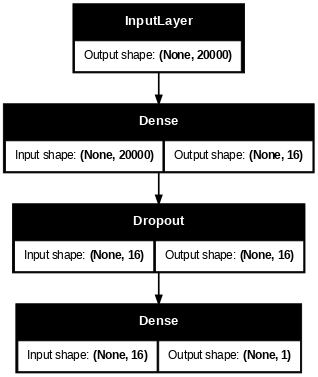

In [14]:
max_tokens=20000
hidden_dim=16

inputs = keras.Input(shape=(max_tokens,))
x = keras.layers.Dense(hidden_dim, activation="relu")(inputs)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

keras.utils.plot_model(model,show_shapes=True,dpi=60)

We do 1.5-2% better in our test accuracy when we add in the bigrams. But, ultimately, the bigrams are only a crude representation of sequence information. We need to switch to proper sequence models to (potentially) do better.

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint("binary_2gram.keras",
                                    save_best_only=True)
]

history = model.fit(binary_2gram_train_ds.cache(),  # Note: using .cache will make it so file opening and data reading are up front, not during each epoch
          validation_data=binary_2gram_val_ds.cache(),
          epochs=10,
          callbacks=callbacks)

model = keras.models.load_model("binary_2gram.keras")

print(f"Test acc: {model.evaluate(binary_2gram_test_ds)[1]:.3f}")

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7850 - loss: 0.4765 - val_accuracy: 0.8998 - val_loss: 0.2599
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9123 - loss: 0.2394 - val_accuracy: 0.9020 - val_loss: 0.2628
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9345 - loss: 0.1965 - val_accuracy: 0.9034 - val_loss: 0.2812
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9442 - loss: 0.1741 - val_accuracy: 0.8972 - val_loss: 0.3089
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9491 - loss: 0.1603 - val_accuracy: 0.8978 - val_loss: 0.3221
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9567 - loss: 0.1555 - val_accuracy: 0.8960 - val_loss: 0.3340
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9590 - loss: 0.1509 - val_accuracy: 0.8922 - val_loss: 0.3537
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9602 - loss: 0.1512 - val_accura

#*Without TF Dataset Pipelines*

Let's say we just want to work with text data in memory... we can do that too... going back to our simple example... note that training will be slower if we do this because TextVectorization happens on the CPU. Typically approach is to use TF Datasets, pre-process the data for training, then take the final model and add the same pre-processing steps as layers at the end, to be able to pass raw text as input and get the associated predictions as output.

In [15]:
import numpy as np
import tensorflow as tf # Make sure to import tensorflow

dataset = [
    "I write, erase, rewrite",
    "Erase again, and then",
    "A poppy blooms.",
]

dataset = np.stack(dataset).reshape(3,1)
dataset = tf.constant(dataset, dtype=tf.string)

labels = np.array([1, 0, 1])

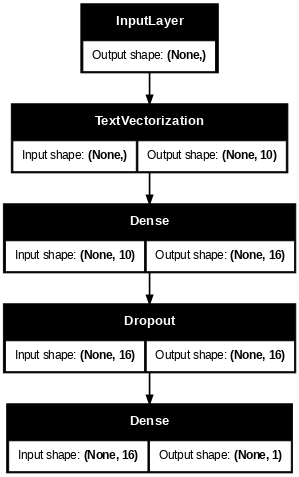

In [16]:
text_vectorization_bigram = keras.layers.TextVectorization(
    max_tokens=10, # adding more tokens to allow for increase due to bigrams.
    output_mode="multi_hot", # This is requesting hot encodings; to get term counts we could request "count" as the output mode, and tf-idf using "tf-idf"
    ngrams=2 # We could also do (1,2) here for both unigrams AND bigrams
)

text_vectorization_bigram.adapt(dataset)

inputs = keras.Input(shape=(), dtype=tf.string) # Be careful! You need to specify a string datatype here, or the model will produce errors when you go to fit.
processing = text_vectorization_bigram(inputs)
x = keras.layers.Dense(hidden_dim, activation="relu")(processing)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

keras.utils.plot_model(model,show_shapes=True,dpi=60)

And finally we fit...

In [17]:
model.fit(dataset,labels,batch_size=1,epochs=10)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6667 - loss: 0.6426
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0000e+00 - loss: 0.8467
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.6044
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6667 - loss: 0.6048
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6667 - loss: 0.7362    
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6667 - loss: 0.6375    
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3333 - loss: 0.7653
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.6293
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.5967
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6667 - loss: 0.6011    
